In [7]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

In [8]:
data <- read_csv("../data/output/combined_hcris_mcaid.csv")

Rows: 60639 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (12): provider_number, fy_start, fy_end, date_processed, date_created, ...
dbl  (35): report, status, year, beds, tot_charges, tot_discounts, net_pat_r...
lgl   (2): npi, expanded
date  (1): date_adopted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Problem 1

In [9]:
mean_uncomp <- data %>%
  filter(year >= 2010, year <= 2018) %>%
  group_by(year) %>%
  summarise(mean_uncomp_care = mean(tot_uncomp_care_charges, na.rm = TRUE) / 1e6) %>%
  mutate(mean_uncomp_care = round(mean_uncomp_care, 3))

print(mean_uncomp)

# A tibble: 9 × 2
   year mean_uncomp_care
  <dbl>            <dbl>
1  2010             17.4
2  2011             17.8
3  2012             19.0
4  2013             19.2
5  2014             15.9
6  2015             15.6
7  2016             20.3
8  2017             23.2
9  2018             26.4


## Problem 2 

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year and expand_group.
ℹ Output is grouped by year.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, expand_group))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


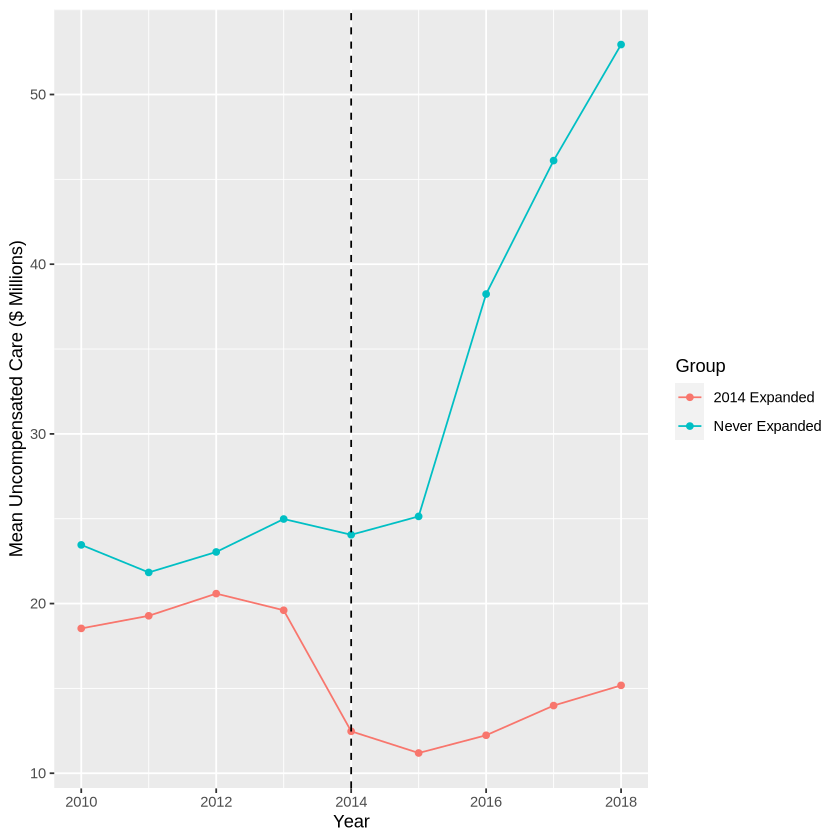

In [10]:
data_filtered <- data %>%
filter(year >= 2010, year <= 2018) %>%
  mutate(expand_group = case_when(
    expanded == FALSE ~ "Never Expanded",
    as.Date(date_adopted) == as.Date("2014-01-01") ~ "2014 Expanded"
  )) %>%
  filter(!is.na(expand_group))

data_filtered %>%
  group_by(year, expand_group) %>%
  summarise(mean_uncomp = mean(tot_uncomp_care_charges, na.rm = TRUE) / 1e6) %>%
  ggplot(aes(x = year, y = mean_uncomp, color = expand_group)) +
  geom_line() + geom_point() +
  geom_vline(xintercept = 2014, linetype = "dashed") +
  labs(x = "Year", y = "Mean Uncompensated Care ($ Millions)", color = "Group")


## Problem 3

In [11]:
data_filtered %>%
  filter(year %in% c(2012, 2015)) %>%
  group_by(expand_group, year) %>%
  summarise(mean_uncomp = mean(tot_uncomp_care_charges, na.rm = TRUE) / 1e6) %>%
  pivot_wider(names_from = year, values_from = mean_uncomp) %>%
  mutate(diff = `2015` - `2012`)

data_filtered$diff[data_filtered$expand_group == "2014 Expanded"] - data_filtered$diff[data_filtered$expand_group == "Never Expanded"]

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by expand_group and year.
ℹ Output is grouped by expand_group.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(expand_group, year))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


expand_group,2012,2015,diff
<chr>,<dbl>,<dbl>,<dbl>
2014 Expanded,20.58612,11.19365,-9.392463
Never Expanded,23.04128,25.13676,2.095481


Warning message:
“Unknown or uninitialised column: `diff`.”
Warning message:
“Unknown or uninitialised column: `diff`.”


integer(0)

## Problem 4

Medicaid expansion decreases uncompensated care which is expected since Medicaid expansion extends coverage to a larger population. Hospitals can file for billing through Medicaid as more patients will be insured, and the volume of charity care or debt will decrease. 

## Problem 5

In [37]:
library(tidyverse)
library(fixest)
library(modelsummary)

In [38]:
reg_dat <- data %>%
  filter(as.Date(date_adopted) == as.Date("2014-01-01") | is.na(date_adopted)) %>%
  mutate(
    post  = (year >= 2014),
    treat = post * expanded
  )

m_dd <- lm(tot_uncomp_care_charges / 1e6 ~ post + expanded + treat, data = reg_dat)

## Problem 6

In [39]:
# Question 6: DD with hospital and year fixed effects (fixest)
m_fe <- feols(tot_uncomp_care_charges / 1e6 ~ post + expanded + treat | provider_number + year,
              cluster = ~ state,
              data = reg_dat)

modelsummary(list("DD" = m_dd, "DD + FE" = m_fe),
             gof_map = NA,
             coef_omit = "Intercept",
             vcov = list(~ state, ~ state))

summary(m_fe)

NOTE: 14,571 observations removed because of NA values (LHS: 14,379, RHS: 3,552).

The variables 'postTRUE' and 'expandedTRUE' have been removed because of collinearity (see $collin.var).



<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
 <thead>
  <tr>
   <th style="text-align:left;">   </th>
   <th style="text-align:center;"> DD </th>
   <th style="text-align:center;"> DD + FE </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> postTRUE </td>
   <td style="text-align:center;"> 17.787 </td>
   <td style="text-align:center;">  </td>
  </tr>
  <tr>
   <td style="text-align:left;">  </td>
   <td style="text-align:center;"> (4.946) </td>
   <td style="text-align:center;">  </td>
  </tr>
  <tr>
   <td style="text-align:left;"> expandedTRUE </td>
   <td style="text-align:center;"> −3.629 </td>
   <td style="text-align:center;">  </td>
  </tr>
  <tr>
   <td style="text-align:left;">  </td>
   <td style="text-align:center;"> (6.378) </td>
   <td style="text-align:center;">  </td>
  </tr>
  <tr>
   <td style="text-align:left;"> treat </td>
   <td style="text-align:center;"> −23.828 </td>
   <td style="text-align:cen

OLS estimation, Dep. Var.: tot_uncomp_care_charges/1e+06
Observations: 29,438 
Fixed-effects: provider_number: 3,497,  year: 10
Standard-errors: Clustered (state) 
      Estimate Std. Error  t value   Pr(>|t|)    
treat -25.3316    5.89188 -4.29941 0.00014276 ***
... 2 variables were removed because of collinearity (postTRUE and expandedTRUE)
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 30.2     Adj. R2: 0.806076
             Within R2: 0.035546

## Problem 7

In [40]:
# Question 7: Same as Q6 but include ALL states (all expanders)
reg_dat_all <- data %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(
    post  = (year >= 2014),
    treat = post * expanded
  )

m_fe_all <- feols(tot_uncomp_care_charges / 1e6 ~ post + expanded + treat | provider_number + year,
                  cluster = ~ state,
                  data = reg_dat_all)

modelsummary(list("DD + FE (2014 only)" = m_fe, "DD + FE (All States)" = m_fe_all),
             gof_map = NA,
             coef_omit = "Intercept",
             vcov = list(~ state, ~ state))

summary(m_fe_all)

NOTE: 17,347 observations removed because of NA values (LHS: 17,161, RHS: 3,162).

The variables 'postTRUE' and 'expandedTRUE' have been removed because of collinearity (see $collin.var).



<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
 <thead>
  <tr>
   <th style="text-align:left;">   </th>
   <th style="text-align:center;">  DD + FE (2014 only) </th>
   <th style="text-align:center;"> DD + FE (All States) </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> treat </td>
   <td style="text-align:center;"> −25.332 </td>
   <td style="text-align:center;"> −18.373 </td>
  </tr>
  <tr>
   <td style="text-align:left;">  </td>
   <td style="text-align:center;"> (5.892) </td>
   <td style="text-align:center;"> (4.737) </td>
  </tr>
</tbody>
</table>

OLS estimation, Dep. Var.: tot_uncomp_care_charges/1e+06
Observations: 36,861 
Fixed-effects: provider_number: 4,852,  year: 9
Standard-errors: Clustered (state) 
      Estimate Std. Error t value  Pr(>|t|)    
treat -18.3734    4.73699 -3.8787 0.0003132 ***
... 2 variables were removed because of collinearity (postTRUE and expandedTRUE)
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 24.7     Adj. R2: 0.817618
             Within R2: 0.025259

## Problem 8

NOTE: 14,571 observations removed because of NA values (LHS: 14,379, RHS: 3,552).



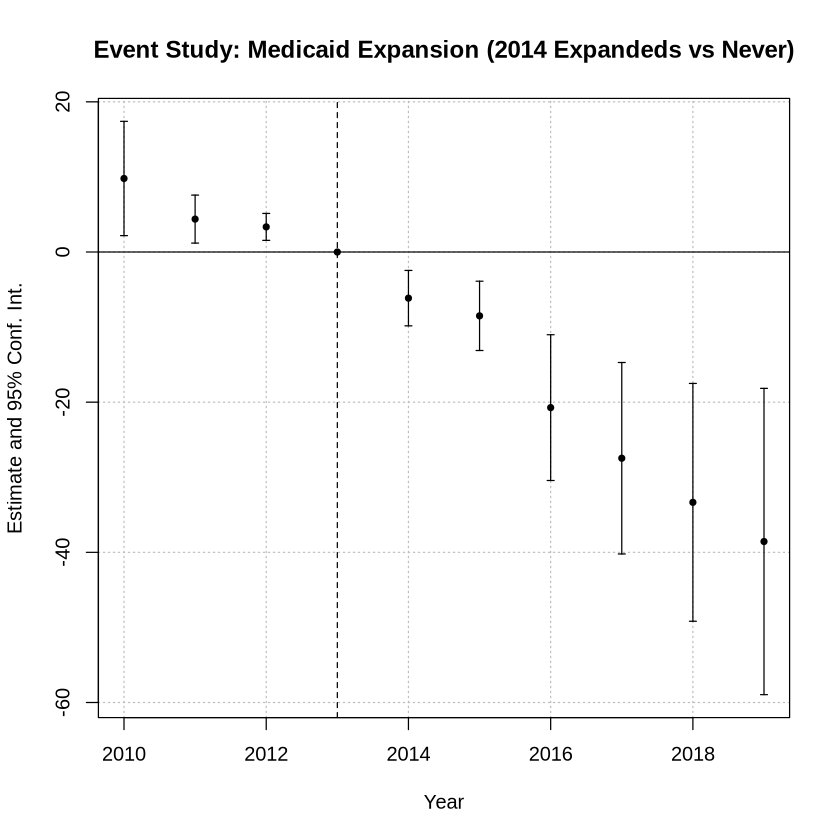

In [25]:
mod_es <- feols(tot_uncomp_care_charges / 1e6 ~ i(year, expanded, ref = 2013) | provider_number + year,
                cluster = ~ state,
                data = reg_dat)

iplot(mod_es, xlab = "Year", main = "Event Study: Medicaid Expansion (2014 Expandeds vs Never)")

## Problem 9

NOTE: 17,347 observations removed because of NA values (LHS: 17,161, RHS: 3,162).



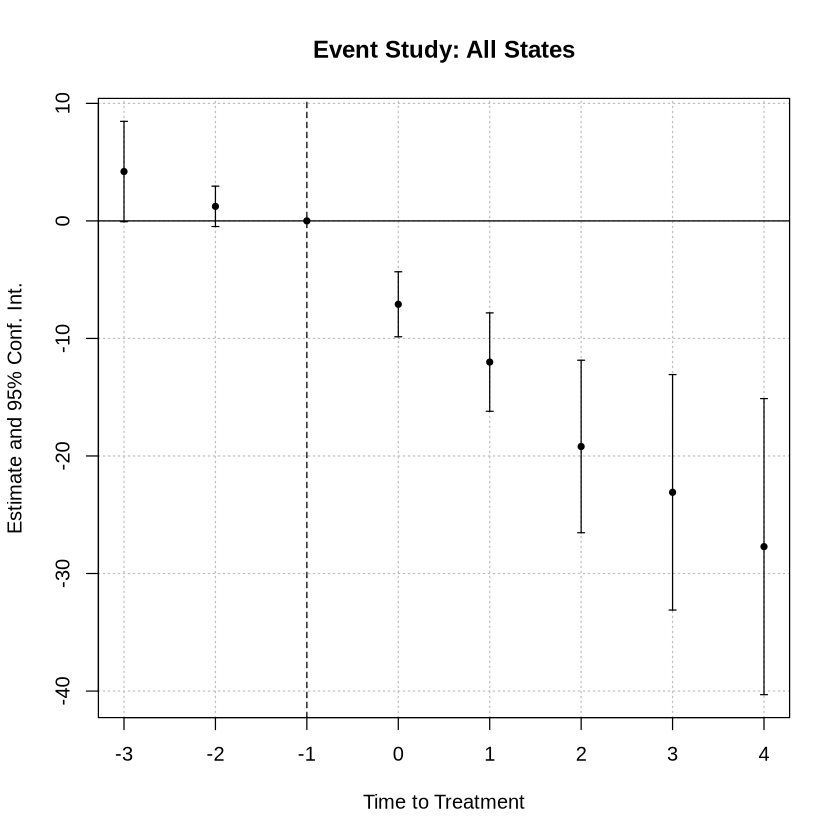

In [28]:
# Question 9: Event study with all states, event time variable, binned endpoints
reg_dat_full <- data %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(
    expand_year   = year(as.Date(date_adopted)),
    time_to_treat = ifelse(expanded == FALSE, 0, year - expand_year),
    time_to_treat = ifelse(time_to_treat < -3, -3, time_to_treat),  # bin left at -3
    time_to_treat = ifelse(time_to_treat > 5, 5, time_to_treat)     # bin right at +5
  )

mod_es_full <- feols(tot_uncomp_care_charges / 1e6 ~ i(time_to_treat, expanded, ref = -1) | provider_number + year,
                     cluster = ~ state,
                     data = reg_dat_full)

iplot(mod_es_full, xlab = "Time to Treatment", main = "Event Study: All States")

## Problem 10

Results show that Medicaid expansion reduces hospital uncompensated care, with effects growing larger over time. The post 2014 downward trend is seen in both event study graphs but the pre-trends in the graphs are not flat, which means we should be cautious interpreting the results as it may be due to an already downward trend. One limitation of the TWFE estimator is that it can be biased when states expand Medicaid at different times. 